# Time Series Dataset Analysis: Seafood Stocks in Thailand

Notebook เป็นการวิเคราะห์ Time Series Dataset จริง โดยใช้ **Seafood Stocks Dataset (2021 - 2026)**

## 1. ข้อมูล Dataset

**Dataset:** ราคาปิดของหุ้น ในกลุ่มบริษัทส่งออก อาหารทะเลของไทย

**แหล่งข้อมูล:** Yahoo Finance

**ช่วงข้อมูล:** มกราคม 2020 – ธันวาคม 2025  

**Sampling Interval:** ทุก 1 วัน

**จำนวนตัวอย่าง:** ประมาณ 1,453 แถว  
				
**ตัวแปร:** 
- บริษัท ไทยยูเนี่ยน กรุ๊ป (ASIAN.BK)
- บริษัท เอเชี่ยนซี คอร์ปอเรชั่น (CFRESH.BK)
- บริษัท ซีเฟรชอินดัสตรี (SSF.BK)
- บริษัท ทรอปิคอลแคนนิ่ง ประเทศไทย (TC.BK)
- บริษัท สุรพลฟู้ดส์ (TU.BK)

**Target:** ทำนายราคาปิดของหุ้นส่งออกอาหารทะเลไทย ในอนาคต


In [ ]:
# นำเข้า Library ที่จำเป็น
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# กำหนดรายชื่อหุ้นกลุ่มอาหารทะเลไทย (ใส่ .BK เพื่อบอกว่าเป็นของ SET)
tickers = ["TU.BK", "ASIAN.BK", "CFRESH.BK", "TC.BK", "SSF.BK"]

# กำหนดวันที่ 
start_date = "2020-01-01"
end_date = "2025-12-31"

# คำสั่งดึงข้อมูลจริงจาก Yahoo Finance
data = yf.download(tickers, start=start_date, end=end_date)

# เลือกเฉพาะ "ราคาปิด" (Close) 
df = data['Close']
df

# นำวันที่ซึ่งเป็น Index ดึงออกมาให้กลายเป็น "คอลัมน์ปกติ"
# df = df.reset_index()

[*********************100%***********************]  5 of 5 completed


Ticker,ASIAN.BK,CFRESH.BK,SSF.BK,TC.BK,TU.BK
Date,,,,,
2020-01-02,1.797801,0.984827,4.323463,2.443219,9.669616
2020-01-03,1.789321,0.971954,5.264863,2.443219,9.882916
2020-01-06,1.746920,0.959080,4.811596,2.382893,9.385214
2020-01-07,1.738440,0.965517,4.811596,2.397974,9.598516
2020-01-08,1.746920,0.952643,4.811596,2.367811,9.456315
...,...,...,...,...,...
2025-12-24,6.721134,0.730000,4.657037,4.745763,11.973128
2025-12-25,6.768135,0.720000,4.703608,4.793221,12.067406
2025-12-26,6.815136,0.720000,4.703608,4.793221,12.067406


In [13]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1453 entries, 2020-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ASIAN.BK   1453 non-null   float64
 1   CFRESH.BK  1453 non-null   float64
 2   SSF.BK     1453 non-null   float64
 3   TC.BK      1453 non-null   float64
 4   TU.BK      1453 non-null   float64
dtypes: float64(5)
memory usage: 68.1 KB


## 2. Dataset Information

In [16]:
# ตรวจสอบข้อมูลพื้นฐาน
print("จำนวนตัวอย่างทั้งหมด:", len(df))
print("ช่วงเวลาเริ่ม:", df.index.min(),"สิ้นสุดที่",df.index.max())
print("\nตัวแปร:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

จำนวนตัวอย่างทั้งหมด: 1453
ช่วงเวลาเริ่ม: 2020-01-02 00:00:00 สิ้นสุดที่ 2025-12-30 00:00:00

ตัวแปร:
01. ASIAN.BK
02. CFRESH.BK
03. SSF.BK
04. TC.BK
05. TU.BK


In [18]:
print("ข้อมูลซ้ำ:", df.index.duplicated().sum())
print("\nMissing Values")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

ข้อมูลซ้ำ: 0

Missing Values


,missing_count
Ticker,
ASIAN.BK,0
CFRESH.BK,0
SSF.BK,0
TC.BK,0
TU.BK,0


In [6]:
# ตรวจสอบ Sampling Interval

time_diff = df.index.to_series().diff().dropna()

print("Sampling interval ที่พบบ่อยที่สุด:")
print(time_diff.value_counts().head(10))

print("\nค่าเฉลี่ยของ interval:", time_diff.mean())

Sampling interval ที่พบบ่อยที่สุด:
Date
1 days    1110
3 days     255
4 days      43
2 days      27
5 days      14
6 days       3
Name: count, dtype: int64

ค่าเฉลี่ยของ interval: 1 days 12:10:54


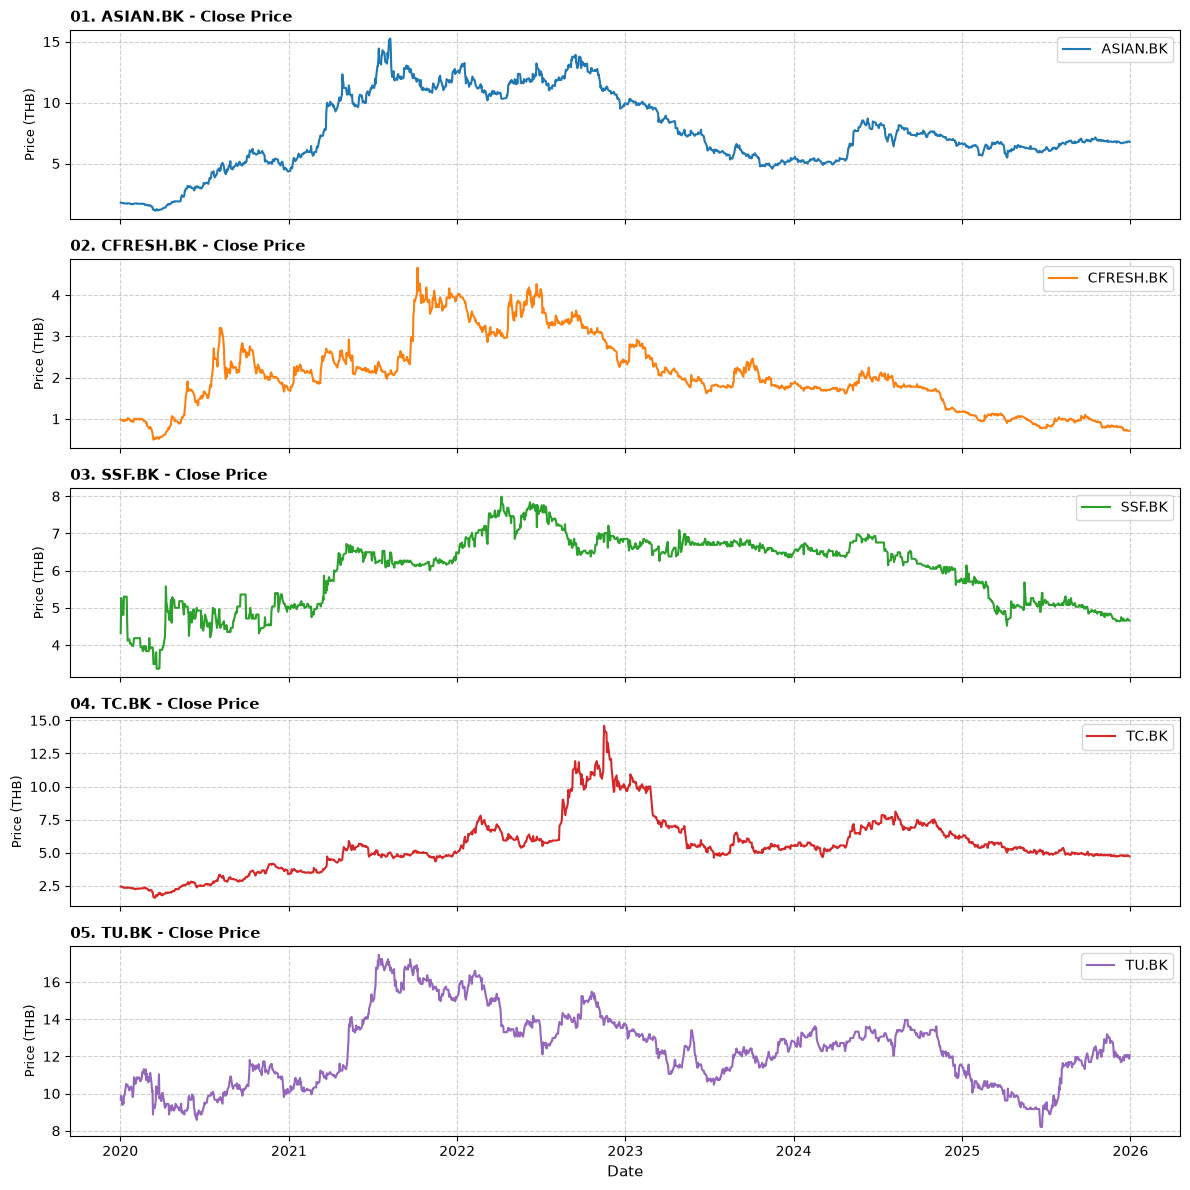

In [7]:
# รายชื่อตัวแปร (หุ้นทั้ง 5 ตัว)
tickers = ['ASIAN.BK', 'CFRESH.BK', 'SSF.BK', 'TC.BK', 'TU.BK']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# สร้าง Subplots 5 แถว 1 คอลัมน์ โดยใช้แกน X (วันที่) ร่วมกัน
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 12), sharex=True)

# วนลูปพล็อตกราฟของหุ้นแต่ละตัวแยกแกน
for i, ticker in enumerate(tickers):
    axes[i].plot(df.index, df[ticker], label=ticker, color=colors[i], linewidth=1.5)
    axes[i].set_title(f"{i+1:02d}. {ticker} - Close Price", fontsize=11, fontweight='bold', loc='left')
    axes[i].set_ylabel("Price (THB)", fontsize=9)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend(loc='upper right')

# ปรับแต่งระยะห่างระหว่างกราฟ
plt.xlabel("Date", fontsize=11)
plt.tight_layout()
plt.show()

## 3 การวิเคราะห์ Trend / Seasonality / Noise

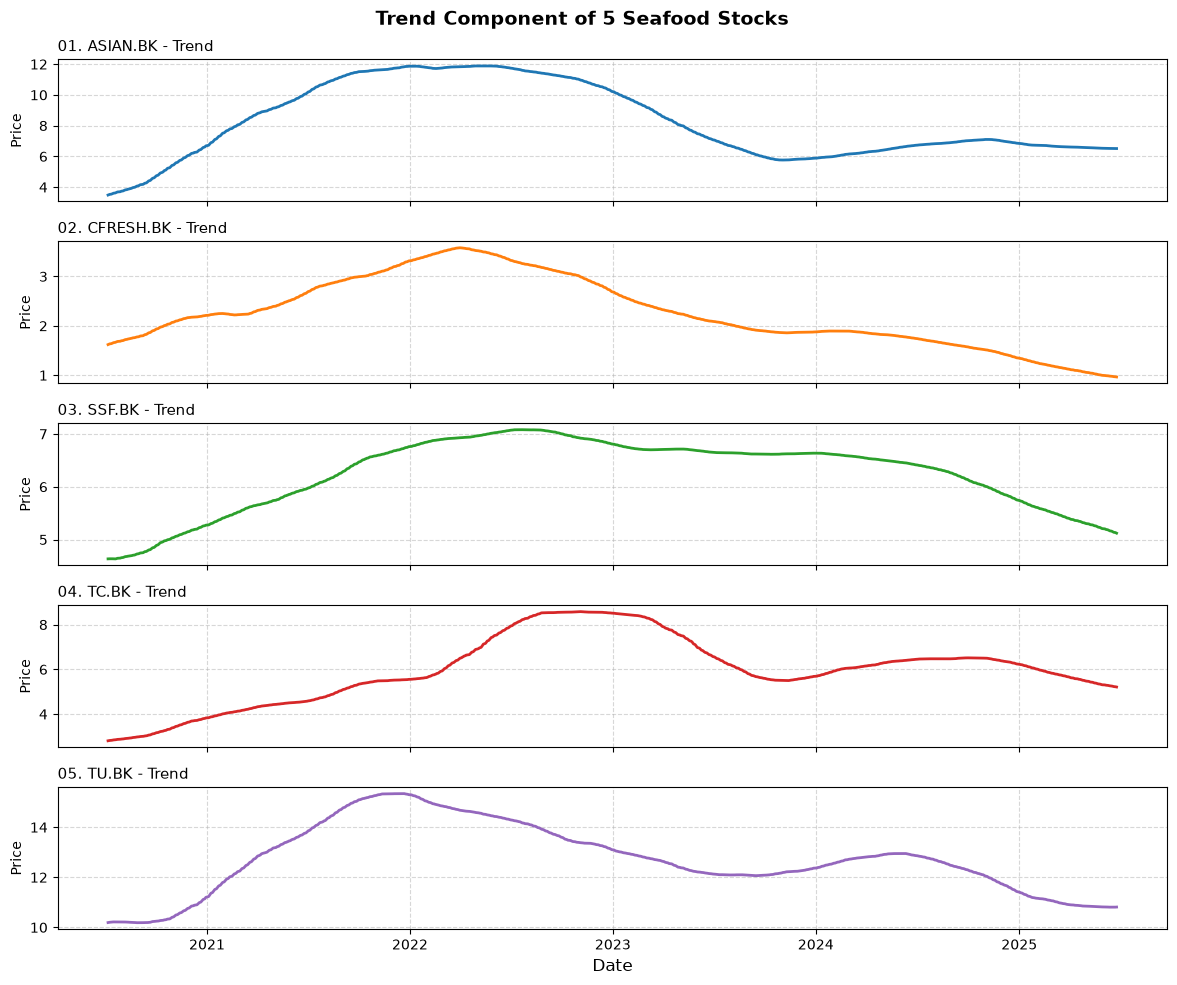

In [8]:
tickers = ["ASIAN.BK", "CFRESH.BK", "SSF.BK", "TC.BK", "TU.BK"]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# พล็อตเฉพาะ Trend
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
fig.suptitle("Trend Component of 5 Seafood Stocks", fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(tickers):
    # คำนวณ Decomposition ล่วงหน้า (ใช้ period=252 สำหรับข้อมูลรายปี)
    decomp = seasonal_decompose(df[ticker].dropna(), model='additive', period=252)

    axes[i].plot(decomp.trend.index, decomp.trend, color=colors[i], linewidth=2)
    axes[i].set_title(f"{i+1:02d}. {ticker} - Trend", fontsize=11, loc='left')
    axes[i].set_ylabel("Price")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

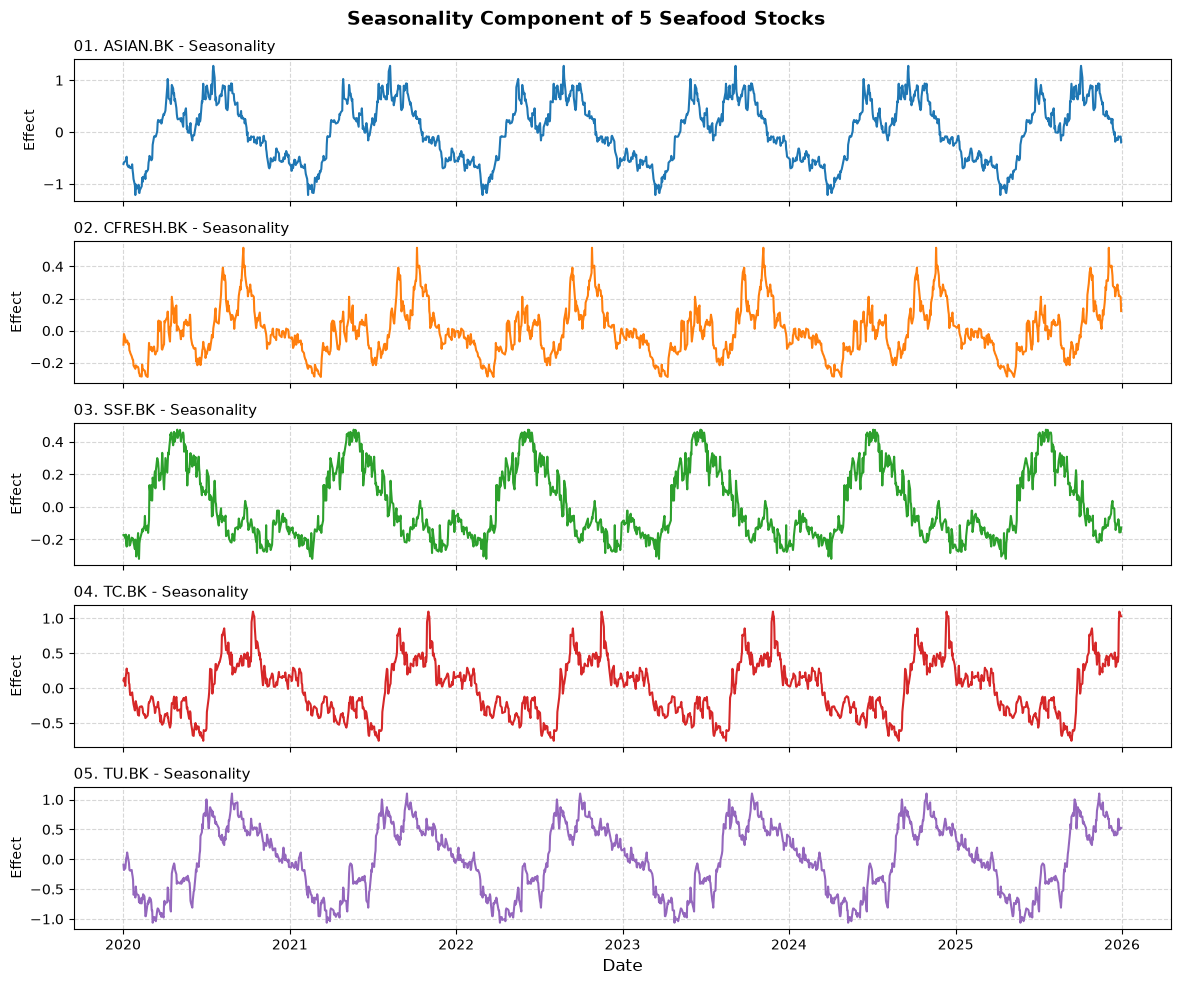

In [9]:
# พล็อตเฉพาะ Seasonality
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
fig.suptitle("Seasonality Component of 5 Seafood Stocks", fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(tickers):
    decomp = seasonal_decompose(df[ticker].dropna(), model='additive', period=252)
    
    axes[i].plot(decomp.seasonal.index, decomp.seasonal, color=colors[i], linewidth=1.5)
    axes[i].set_title(f"{i+1:02d}. {ticker} - Seasonality", fontsize=11, loc='left')
    axes[i].set_ylabel("Effect")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

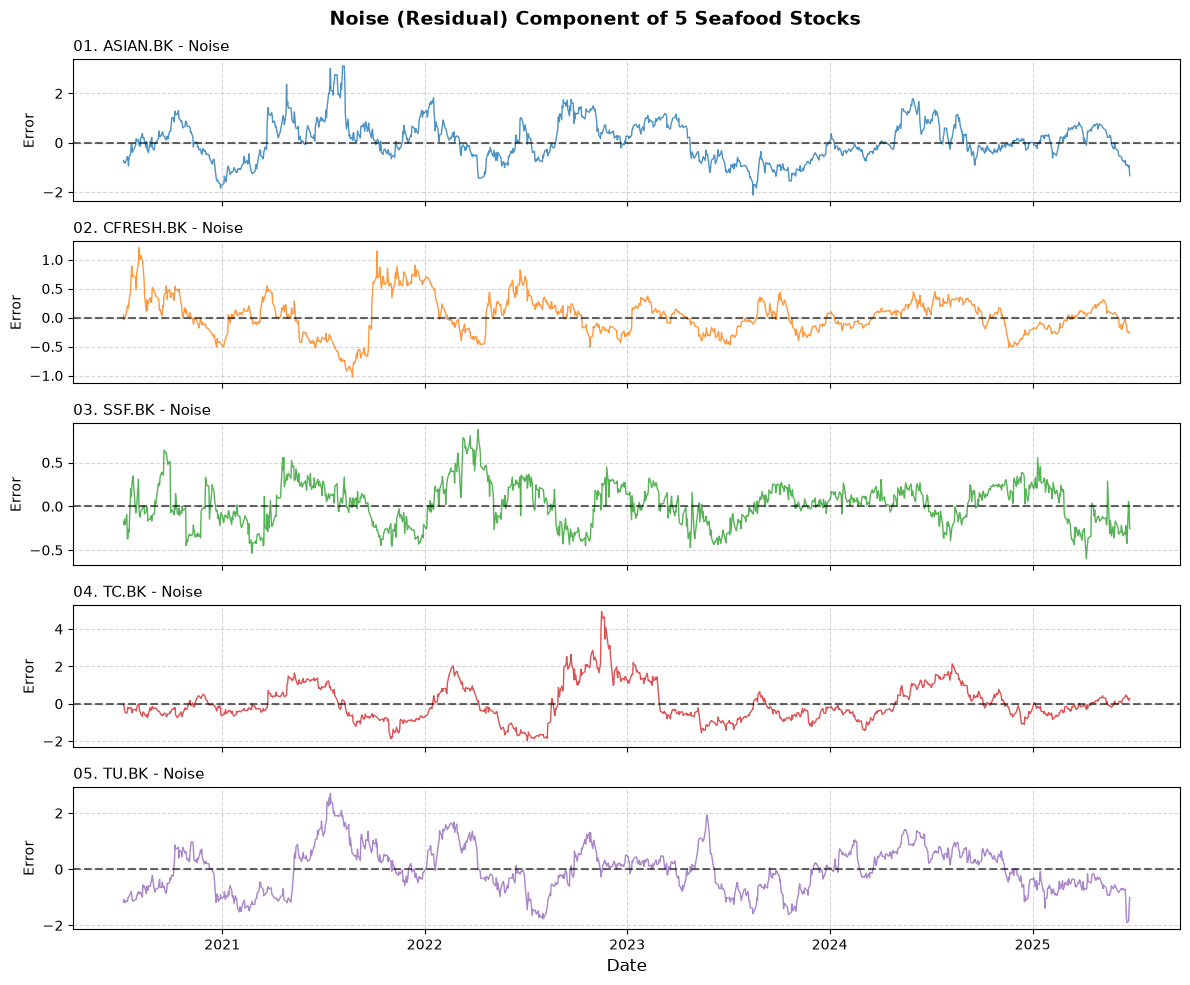

In [10]:
# พล็อตเฉพาะ Noise 
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)
fig.suptitle("Noise (Residual) Component of 5 Seafood Stocks", fontsize=14, fontweight='bold', y=0.98)

for i, ticker in enumerate(tickers):
    decomp = seasonal_decompose(df[ticker].dropna(), model='additive', period=252)
    
    axes[i].plot(decomp.resid.index, decomp.resid, color=colors[i], linewidth=1, alpha=0.8)
    axes[i].axhline(0, color='black', linestyle='--', alpha=0.6) # เส้นศูนย์เพื่อดูการแกว่งตัว
    axes[i].set_title(f"{i+1:02d}. {ticker} - Noise", fontsize=11, loc='left')
    axes[i].set_ylabel("Error")
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel("Date", fontsize=12)
plt.tight_layout()
plt.show()

**Trend:** อุณหภูมิเปลี่ยนแปลงตามช่วงเวลาในระยะยาว โดยมีรูปแบบขึ้นลงตามปีและฤดูกาล

**Seasonality:** มีรูปแบบซ้ำตามเวลา โดยเฉพาะ
- Daily seasonality: กลางวัน/กลางคืน
- Yearly/Annual seasonality: ฤดูร้อน/ฤดูหนาว

**Noise:** มีการแกว่งระยะสั้นจากสภาพอากาศจริง ทำให้ค่าที่ติดกันไม่ได้เท่ากันตลอดเวลา

เพื่อแยก Pattern ระยะยาวออกจาก Noise จะใช้ Rolling Mean

## 4. การจัดการ Missing Values, Noise, Scaling/Normalization และ Feature Engineering หากมี

แนวทางจัดการ Missing Values สำหรับ Time Series ควรคำนึงถึงลำดับเวลา

ในตัวอย่างนี้:
1. ตรวจสอบจำนวน Missing Values ก่อน
2. ใช้ **Time-based Interpolation** สำหรับตัวแปรเชิงตัวเลข
3. ตรวจสอบอีกครั้งหลังการเติมค่า

ไม่ควรเติมค่าแบบสุ่ม เพราะค่าที่หายไปควรสัมพันธ์กับข้อมูลก่อนหน้าและหลังหน้าในลำดับเวลา

In [11]:
# 9.1 Missing Values ก่อนจัดการ

missing_before = df.isna().sum().sort_values(ascending=False)
display(missing_before.to_frame("missing_before"))

# ทำสำเนาเฉพาะข้อมูลดิบก่อนสร้าง feature
data = df.drop(columns=["temp_roll_1h", "temp_roll_1d"], errors="ignore").copy()

# Interpolation ตามเวลา
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].interpolate(method="time")

# เผื่อกรณีหัว/ท้ายยังเป็น NaN
data[numeric_cols] = data[numeric_cols].bfill().ffill()

missing_after = data.isna().sum().sort_values(ascending=False)
display(missing_after.to_frame("missing_after"))

,missing_before
Ticker,
ASIAN.BK,0
CFRESH.BK,0
SSF.BK,0
TC.BK,0
TU.BK,0


,missing_after
Ticker,
ASIAN.BK,0
CFRESH.BK,0
SSF.BK,0
TC.BK,0
TU.BK,0


## 10. Noise Management

Noise เป็นส่วนหนึ่งของข้อมูลจริง จึงไม่ควรลบค่าที่ผิดปกติออกทั้งหมดโดยไม่ตรวจสอบ

แนวทางตัวอย่าง:
- ใช้ Rolling Median เพื่อดูค่าที่ผิดปกติระยะสั้น
- ใช้ IQR ตรวจสอบ Outlier ในเชิงสถิติ
- ไม่ลบ Outlier โดยอัตโนมัติ เพราะอุณหภูมิที่เปลี่ยนแปลงเร็วอาจเป็นเหตุการณ์จริง

ด้านล่างจะสร้างคอลัมน์สำหรับตรวจสอบ Outlier ด้วย IQR

In [12]:
# 10.1 ตรวจสอบ Outlier ของ Target ด้วย IQR

q1 = data[TARGET].quantile(0.25)
q3 = data[TARGET].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outlier_mask = (data[TARGET] < lower) | (data[TARGET] > upper)

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("จำนวนค่าที่เข้าข่าย IQR outlier:", outlier_mask.sum())
print("สัดส่วน:", f"{outlier_mask.mean()*100:.4f}%")

NameError: name 'TARGET' is not defined

In [ ]:
# 10.2 แสดงตัวอย่างค่าที่เป็น Outlier

outlier_sample = data.loc[outlier_mask, [TARGET]].head(20)
display(outlier_sample)

,T (degC)
Date Time,
2009-01-06 04:50:00,-14.90
2009-01-06 05:00:00,-15.13
2009-01-06 05:10:00,-15.20
2009-01-06 05:20:00,-15.16
2009-01-06 05:30:00,-15.25
2009-01-06 05:40:00,-15.31
2009-01-06 05:50:00,-15.29
2009-01-06 06:00:00,-15.37
2009-01-06 06:10:00,-15.49


### ข้อสรุปเรื่อง Noise

ในงาน Time Series จริง ควรแยกคำว่า **Noise** ออกจาก **Outlier**:

- Noise = การแกว่งเล็ก ๆ ที่เกิดขึ้นตามธรรมชาติของการวัด
- Outlier = ค่าที่ผิดจากช่วงปกติมาก
- Outlier ไม่ได้แปลว่า "ข้อมูลผิด" เสมอไป

ดังนั้น Notebook นี้จะ **ไม่ลบ Outlier ทั้งหมด** แต่เก็บข้อมูลจริงไว้ และใช้ Rolling/Feature Engineering ช่วยให้โมเดลเรียนรู้รูปแบบได้ดีขึ้น

## 11. Feature Engineering

ตัวอย่าง Feature สำหรับ Time Series:

**Time Features**
- Hour
- Day of week
- Month

**Lag Features**
- ค่าอุณหภูมิเมื่อ 10 นาทีที่แล้ว
- ค่าเมื่อ 1 ชั่วโมงที่แล้ว
- ค่าเมื่อ 1 วันก่อน

**Rolling Features**
- ค่าเฉลี่ยย้อนหลัง 1 ชั่วโมง
- ค่าเฉลี่ยย้อนหลัง 6 ชั่วโมง
- ค่า Standard Deviation ย้อนหลัง 1 ชั่วโมง

Feature เหล่านี้ช่วยให้โมเดลรู้บริบทของเวลาและอดีต

In [ ]:
# 12. สร้าง Feature Engineering

fe = data.copy()

# Time features
fe["hour"] = fe.index.hour
fe["day_of_week"] = fe.index.dayofweek
fe["month"] = fe.index.month
fe["day_of_year"] = fe.index.dayofyear

# Cyclical encoding
fe["hour_sin"] = np.sin(2 * np.pi * fe["hour"] / 24)
fe["hour_cos"] = np.cos(2 * np.pi * fe["hour"] / 24)

fe["month_sin"] = np.sin(2 * np.pi * fe["month"] / 12)
fe["month_cos"] = np.cos(2 * np.pi * fe["month"] / 12)

# Lag features
fe["lag_10min"] = fe[TARGET].shift(1)
fe["lag_1h"] = fe[TARGET].shift(6)
fe["lag_6h"] = fe[TARGET].shift(36)
fe["lag_1d"] = fe[TARGET].shift(144)

# Rolling features
fe["rolling_mean_1h"] = fe[TARGET].rolling(6).mean()
fe["rolling_std_1h"] = fe[TARGET].rolling(6).std()

fe["rolling_mean_6h"] = fe[TARGET].rolling(36).mean()
fe["rolling_mean_1d"] = fe[TARGET].rolling(144).mean()

# ลบแถวต้น ๆ ที่เกิด NaN จาก lag/rolling
fe = fe.dropna()

print("Shape หลัง Feature Engineering:", fe.shape)
display(fe.head())

Shape หลัง Feature Engineering: (420407, 30)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),hour,day_of_week,month,day_of_year,hour_sin,hour_cos,month_sin,month_cos,lag_10min,lag_1h,lag_6h,lag_1d,rolling_mean_1h,rolling_std_1h,rolling_mean_6h,rolling_mean_1d
Date Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2009-01-02 00:10:00,999.55,-4.60,268.60,-5.52,93.2,4.34,4.04,0.29,2.52,4.04,1294.58,0.85,1.38,151.2,0,4,1,2,0.0,1.0,0.5,0.866025,-4.54,-4.50,-5.16,-8.02,-4.481667,0.121559,-4.730556,-6.771111
2009-01-02 00:20:00,999.56,-4.67,268.53,-5.52,93.7,4.32,4.04,0.27,2.52,4.05,1294.91,0.83,1.50,148.8,0,4,1,2,0.0,1.0,0.5,0.866025,-4.60,-4.51,-5.12,-8.41,-4.508333,0.144418,-4.718056,-6.745139
2009-01-02 00:30:00,999.56,-4.66,268.53,-5.46,94.1,4.32,4.06,0.25,2.53,4.06,1294.89,0.53,1.38,154.3,0,4,1,2,0.0,1.0,0.5,0.866025,-4.67,-4.33,-5.04,-8.51,-4.563333,0.124365,-4.707500,-6.718403
2009-01-02 00:40:00,999.48,-4.55,268.65,-5.31,94.4,4.35,4.11,0.24,2.56,4.11,1294.22,0.41,1.25,159.3,0,4,1,2,0.0,1.0,0.5,0.866025,-4.66,-4.33,-5.01,-8.31,-4.600000,0.054772,-4.694722,-6.692292
2009-01-02 00:50:00,999.44,-4.43,268.77,-5.19,94.4,4.39,4.15,0.25,2.59,4.15,1293.56,0.63,1.13,192.1,0,4,1,2,0.0,1.0,0.5,0.866025,-4.55,-4.58,-5.12,-8.27,-4.575000,0.089163,-4.675556,-6.665625


## 13. Scaling / Normalization

สำหรับ Machine Learning เราควร Scale Feature เพื่อให้ค่าของตัวแปรอยู่ในช่วงที่เหมาะสม

ใน Notebook นี้เลือกใช้:

**StandardScaler**
\[
z = \frac{x-\mu}{\sigma}
\]

ข้อสำคัญมากสำหรับ Time Series คือ:

> ต้อง `fit()` scaler ด้วยข้อมูล **Train เท่านั้น**

ห้าม fit จาก Validation หรือ Test เพราะจะทำให้เกิด **Data Leakage**

In [ ]:
# 14. แบ่ง Train / Validation / Test ตามลำดับเวลา

n = len(fe)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = fe.iloc[:train_end].copy()
val = fe.iloc[train_end:val_end].copy()
test = fe.iloc[val_end:].copy()

print("Train:", train.shape, train.index.min(), "->", train.index.max())
print("Validation:", val.shape, val.index.min(), "->", val.index.max())
print("Test:", test.shape, test.index.min(), "->", test.index.max())

Train: (294284, 30) 2009-01-02 00:10:00 -> 2014-08-05 09:30:00
Validation: (63061, 30) 2014-08-05 09:40:00 -> 2015-10-17 23:30:00
Test: (63062, 30) 2015-10-17 23:40:00 -> 2017-01-01 00:00:00


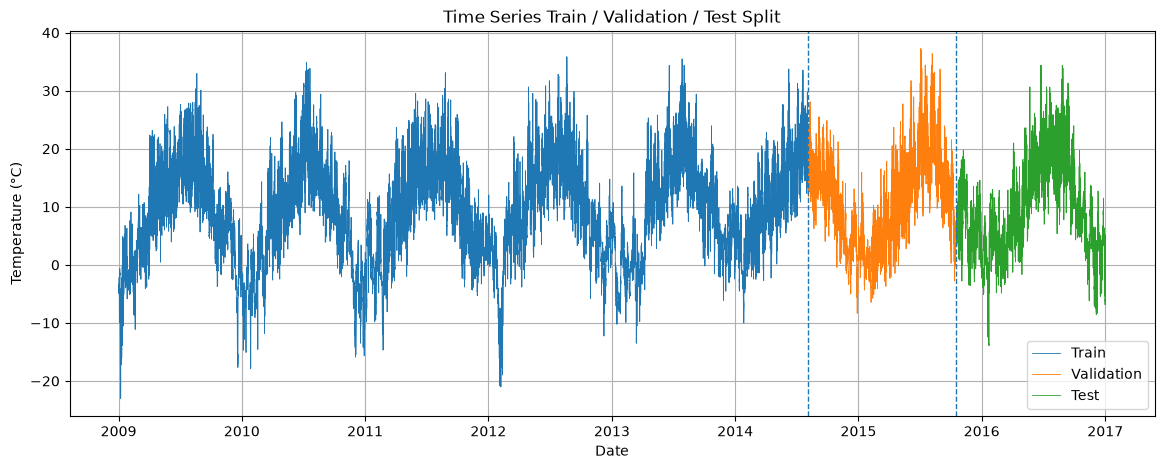

In [ ]:
# 15. Visualize Time-based Split

fig, ax = plt.subplots()

ax.plot(train.index, train[TARGET], label="Train", linewidth=0.6)
ax.plot(val.index, val[TARGET], label="Validation", linewidth=0.6)
ax.plot(test.index, test[TARGET], label="Test", linewidth=0.6)

ax.axvline(val.index.min(), linestyle="--", linewidth=1)
ax.axvline(test.index.min(), linestyle="--", linewidth=1)

ax.set_title("Time Series Train / Validation / Test Split")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.show()

## 16. Scaling โดย Fit จาก Train เท่านั้น

ขั้นตอน:
1. เลือก Feature ที่ใช้
2. `fit_transform()` เฉพาะ Train
3. `transform()` กับ Validation
4. `transform()` กับ Test

วิธีนี้ช่วยป้องกัน Data Leakage

In [ ]:
# 16.1 เลือก Feature และ Target

feature_cols = [
    "p (mbar)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "hour",
    "day_of_week",
    "month",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "lag_10min",
    "lag_1h",
    "lag_6h",
    "lag_1d",
    "rolling_mean_1h",
    "rolling_std_1h",
    "rolling_mean_6h",
    "rolling_mean_1d"
]

X_train = train[feature_cols]
y_train = train[TARGET]

X_val = val[feature_cols]
y_val = val[TARGET]

X_test = test[feature_cols]
y_test = test[TARGET]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (294284, 27)
X_val_scaled: (63061, 27)
X_test_scaled: (63062, 27)


In [ ]:
# 17. ตรวจสอบว่า Scaling ทำงานถูกต้อง

scaled_train_df = pd.DataFrame(X_train_scaled, columns=feature_cols)

check = pd.DataFrame({
    "mean_after_scaling": scaled_train_df.mean(),
    "std_after_scaling": scaled_train_df.std()
})

display(check.head(10))

,mean_after_scaling,std_after_scaling
p (mbar),9.960791e-15,1.000002
Tpot (K),3.146164e-15,1.000002
Tdew (degC),-6.181068e-18,1.000002
rh (%),-2.812386e-16,1.000002
VPmax (mbar),8.035388e-17,1.000002
VPact (mbar),-3.523209e-16,1.000002
VPdef (mbar),-3.399587e-17,1.000002
sh (g/kg),-6.181068e-17,1.000002
H2OC (mmol/mol),4.141316e-16,1.000002
rho (g/m**3),-3.498484e-15,1.000002


## 18. ทำไมไม่ควรสุ่มข้อมูลแบบทั่วไป?

สำหรับข้อมูล Time Series ข้อมูลแต่ละแถวมี **ลำดับเวลาและความสัมพันธ์กับอดีต**

ตัวอย่าง:
- เราต้องการทำนายอุณหภูมิวันที่ 10 มกราคม
- ข้อมูลของวันที่ 11 มกราคมไม่ควรถูกนำมาใช้เป็นข้อมูล Train เพื่อทำนายวันที่ 10 มกราคม

ถ้าใช้ `train_test_split(..., shuffle=True)` จะเกิดปัญหา:

### 1. Data Leakage
ข้อมูลอนาคตอาจหลุดเข้าไปใน Train

### 2. ผิดลักษณะการใช้งานจริง
ระบบจริงจะรู้เฉพาะอดีต ไม่รู้อนาคต

### 3. ประเมินผลดีเกินจริง
โมเดลอาจได้คะแนนสูง แต่เมื่อนำไปใช้จริงกลับทำงานแย่

ดังนั้น Time Series ควรแบ่งข้อมูลเป็น:

**อดีต → Train → Validation → Test → อนาคต**

โดยรักษาลำดับเวลาเอาไว้

In [ ]:
# 19. สรุปข้อมูลสำหรับรายงาน

summary = pd.DataFrame({
    "รายการ": [
        "Dataset",
        "แหล่งข้อมูล",
        "จำนวนตัวอย่างก่อน Feature Engineering",
        "จำนวนตัวอย่างหลัง Feature Engineering",
        "Sampling Interval",
        "Target",
        "Train",
        "Validation",
        "Test",
        "Scaling",
        "Missing Value Method",
        "Noise / Outlier Method"
    ],
    "รายละเอียด": [
        "Jena Climate Dataset",
        "Max Planck Institute / TensorFlow Dataset mirror",
        len(data),
        len(fe),
        "10 minutes",
        TARGET,
        f"{len(train)} ({len(train)/len(fe):.0%})",
        f"{len(val)} ({len(val)/len(fe):.0%})",
        f"{len(test)} ({len(test)/len(fe):.0%})",
        "StandardScaler (fit จาก Train เท่านั้น)",
        "Time interpolation + backward/forward fill",
        "ตรวจสอบ IQR และไม่ลบ Outlier อัตโนมัติ"
    ]
})

display(summary)

,รายการ,รายละเอียด
0,Dataset,Jena Climate Dataset
1,แหล่งข้อมูล,Max Planck Institute / TensorFlow Dataset mirror
2,จำนวนตัวอย่างก่อน Feature Engineering,420551
3,จำนวนตัวอย่างหลัง Feature Engineering,420407
4,Sampling Interval,10 minutes
5,Target,T (degC)
6,Train,294284 (70%)
7,Validation,63061 (15%)
8,Test,63062 (15%)
9,Scaling,StandardScaler (fit จาก Train เท่านั้น)


# 20. สรุปสำหรับเขียนรายงาน

### Dataset
เลือกใช้ **Jena Climate Dataset** ซึ่งเป็นข้อมูลสภาพอากาศจริงจากสถานีตรวจวัดในเมือง Jena ประเทศเยอรมนี บันทึกข้อมูลทุก 10 นาที

### Trend / Seasonality / Noise
ข้อมูลอุณหภูมิมีรูปแบบการเปลี่ยนแปลงระยะยาวและรูปแบบตามฤดูกาล รวมถึงความผันผวนระยะสั้นจากสภาพอากาศจริง

### Missing Values
ตรวจสอบ Missing Values และใช้ Time-based Interpolation โดยอาศัยข้อมูลตามลำดับเวลา

### Noise
ไม่ลบค่าผิดปกติทั้งหมด เพราะค่าที่ดูผิดปกติอาจเป็นเหตุการณ์จริง จึงใช้ IQR เพื่อตรวจสอบ และใช้ Rolling Statistics เพื่อช่วยลดผลกระทบของความผันผวนระยะสั้นในการสร้าง Feature

### Scaling
ใช้ StandardScaler และ `fit()` เฉพาะ Train เพื่อป้องกัน Data Leakage

### Feature Engineering
สร้าง Time Features, Cyclical Features, Lag Features และ Rolling Features เพื่อให้โมเดลสามารถใช้ข้อมูลในอดีตและรูปแบบตามเวลาได้

### Train / Validation / Test
แบ่งข้อมูลตามลำดับเวลา **70% / 15% / 15%** โดยไม่ Shuffle เพื่อจำลองการใช้งานจริง ซึ่งโมเดลจะใช้ข้อมูลอดีตเพื่อทำนายอนาคต